# 4 · Visualizing results

After fitting, WHISPER provides `plot_corner` (posterior overlays), the validation metrics (`recovery_metrics`, `waic`), and posterior-predictive checks. We reuse the synthetic fit from notebook 3.

In [1]:
import numpy as np
import whisper_labia as wp

MODEL = 'gaussian_rise'
truth = {'amplitude': 5.0, 't0': 8.0, 'sigma_rise': 3.0, 'tau_decay': 15.0}
t = np.linspace(0.1, 30, 60)
clean = wp.get_model(MODEL).predict(truth, t, None)
err = np.full_like(clean, 0.1)
obs = clean + np.random.default_rng(0).normal(0, err)
lc = wp.LightCurve(time=t, band=['r'] * len(t), flux=obs, flux_err=err, name='synthetic')
prior = wp.Prior({'amplitude': wp.Uniform(0, 20), 't0': wp.Uniform(0, 20),
                  'sigma_rise': wp.Uniform(0.5, 10), 'tau_decay': wp.Uniform(1, 40)})
abc = wp.fit_ABC(lc, MODEL, prior=prior, n_simulations=20000, quantile=0.01, seed=0)
mc  = wp.fit_MCMC(lc, MODEL, prior=prior, nsteps=2000, burnin=500, seed=0)

## Corner plot

`plot_corner` overlays any number of posteriors on shared axes, with the truth marked. Pass a list of `SamplerResult.samples` (or DataFrames) and matching labels.

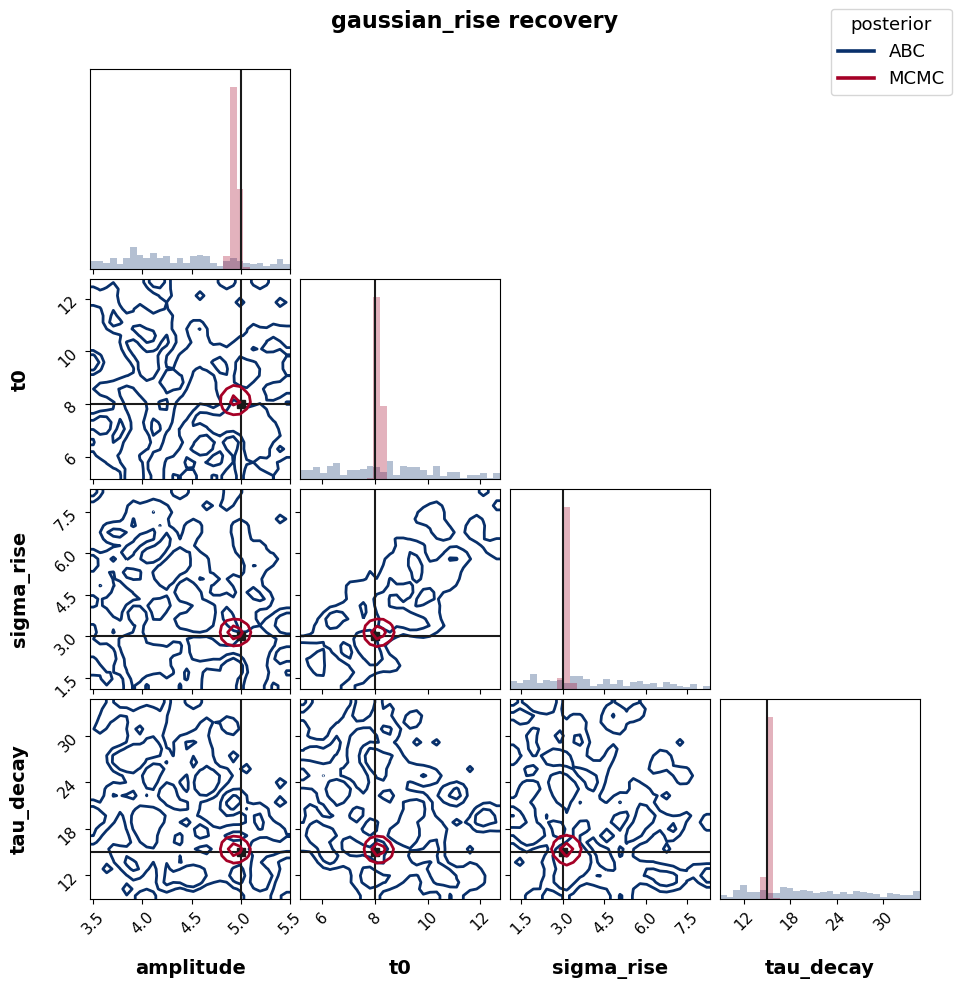

In [2]:
fig = wp.plot_corner([abc.samples, mc.samples], labels=['ABC', 'MCMC'],
                     parameters=['amplitude', 't0', 'sigma_rise', 'tau_decay'],
                     truths=truth, title='gaussian_rise recovery')

## Recovery metrics

`recovery_metrics` scores a fit against a known truth: per-parameter bias, standardized z-score (|z|≲2 ⇒ recovered), and 68/95% credible-interval coverage.

In [3]:
import pandas as pd
m = wp.recovery_metrics(mc, truth)
pd.DataFrame(m).T[['median', 'bias', 'z_score', 'within_68', 'within_95']]

,median,bias,z_score,within_68,within_95
amplitude,4.94239,-0.05761,-1.812802,False,True
t0,8.146722,0.146722,1.875101,False,True
sigma_rise,3.126911,0.126911,1.849699,False,True
tau_decay,15.274555,0.274555,1.183073,False,True
_summary,NaN,NaN,NaN,NaN,NaN


## WAIC

`waic` is a fully-Bayesian fit score (lower = better) usable for model comparison across samplers that share the data + likelihood.

In [4]:
print('MCMC WAIC:', round(wp.waic(mc, lc, MODEL)['waic'], 1))

MCMC WAIC: -118.6


/tmp/ipykernel_17253/4060939042.py:1: UserWarning: WAIC: posterior has 2400 draws; evaluated a random 2000-draw subsample (raise max_samples for the full set).
  print('MCMC WAIC:', round(wp.waic(mc, lc, MODEL)['waic'], 1))


**Next:** [5 · Bayesian model comparison](05_bayesian_model_comparison.ipynb) — the full workflow on real kilonova data.